In [5]:
!pip install requests beautifulsoup4

In [6]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [7]:
url = "https://books.toscrape.com/"

response = requests.get(url)

soup = BeautifulSoup(response.text, "html.parser")

books = []

for book in soup.select("article.product_pod"):
    title = book.h3.a["title"]
    price = book.select_one(".price_color").text
    rating = book.select_one("p.star-rating")["class"][1]

    books.append([title, price, rating])

df = pd.DataFrame(books, columns=["Title", "Price", "Rating"])

print(df.head())

                                   Title    Price Rating
0                   A Light in the Attic  Â£51.77  Three
1                     Tipping the Velvet  Â£53.74    One
2                             Soumission  Â£50.10    One
3                          Sharp Objects  Â£47.82   Four
4  Sapiens: A Brief History of Humankind  Â£54.23   Five


In [8]:
df["Price"] = df["Price"].str.replace("₹", "", regex=False)
df["Price"] = df["Price"].str.strip()
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [9]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

In [10]:
x = df[["Price","Rating"]]
print(x.head())

   Price  Rating
0    NaN       3
1    NaN       1
2    NaN       1
3    NaN       4
4    NaN       5


In [11]:
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

print(model)

KMeans(n_clusters=3, n_init=10, random_state=42)


In [12]:
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans

X = df.select_dtypes(include="number")

# Replace missing (NaN) values
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)

# Create KMeans model
model = KMeans(n_clusters=3, n_init=10, random_state=42)

# Create cluster column
df["Cluster"] = model.fit_predict(X)

# Display result
print(df.head())

                                   Title  Price  Rating  Cluster
0                   A Light in the Attic    NaN       3        2
1                     Tipping the Velvet    NaN       1        0
2                             Soumission    NaN       1        0
3                          Sharp Objects    NaN       4        1
4  Sapiens: A Brief History of Humankind    NaN       5        1


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Price']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [13]:
print(df["Cluster"].value_counts())

Cluster
1    8
2    6
0    6
Name: count, dtype: int64


In [14]:
print(df.head(10))

                                               Title  Price  Rating  Cluster
0                               A Light in the Attic    NaN       3        2
1                                 Tipping the Velvet    NaN       1        0
2                                         Soumission    NaN       1        0
3                                      Sharp Objects    NaN       4        1
4              Sapiens: A Brief History of Humankind    NaN       5        1
5                                    The Requiem Red    NaN       1        0
6  The Dirty Little Secrets of Getting Your Dream...    NaN       4        1
7  The Coming Woman: A Novel Based on the Life of...    NaN       3        2
8  The Boys in the Boat: Nine Americans and Their...    NaN       4        1
9                                    The Black Maria    NaN       1        0


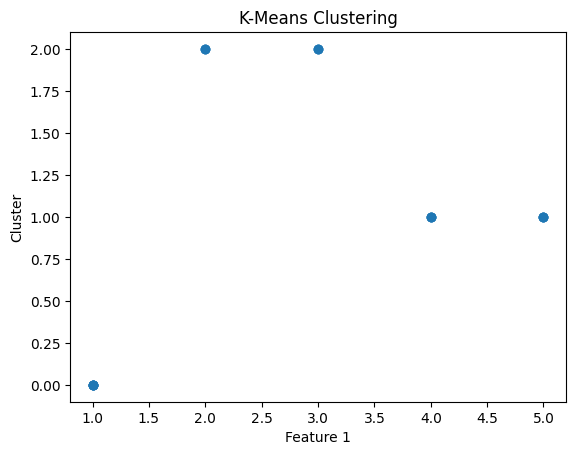

In [19]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], df["Cluster"])

plt.xlabel("Feature 1")
plt.ylabel("Cluster")
plt.title("K-Means Clustering")
plt.show()

In [20]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, df["Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.7280952380952381


In [21]:
print(df.head(10))

                                               Title  Price  Rating  Cluster
0                               A Light in the Attic    NaN       3        2
1                                 Tipping the Velvet    NaN       1        0
2                                         Soumission    NaN       1        0
3                                      Sharp Objects    NaN       4        1
4              Sapiens: A Brief History of Humankind    NaN       5        1
5                                    The Requiem Red    NaN       1        0
6  The Dirty Little Secrets of Getting Your Dream...    NaN       4        1
7  The Coming Woman: A Novel Based on the Life of...    NaN       3        2
8  The Boys in the Boat: Nine Americans and Their...    NaN       4        1
9                                    The Black Maria    NaN       1        0


In [22]:
print(df["Cluster"].value_counts())

Cluster
1    8
2    6
0    6
Name: count, dtype: int64
